We are pleased to share our research on energy demand and generation, with data collected fresh from Spain! We focused our research on time-related dependencies, obtaining two hypothesis on energy use that we confirmed with statistical tests.

The roles in the team were distributed as follows:

Nikita - Data cleanup & broad analysis
Alima - Hypothesis formulation and statistical tests
Both of us made contributions to the API and Web interface, as well as to the vast collection of plots and graphs presented in our report.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

## 1. Data Cleanup

In [4]:
energy_df = pd.read_csv('energy_dataset.csv.zip')
weather_df = pd.read_csv('weather_features.csv.zip')

energy_df['time'] = pd.to_datetime(energy_df['time'], utc=True)
weather_df['dt_iso'] = pd.to_datetime(weather_df['dt_iso'], utc=True)

#drop NaN columns
energy_df = energy_df.dropna(axis=1, how='all')
weather_df = weather_df.drop_duplicates(subset=['dt_iso', 'city_name'])

#average weather across cities per hour
weather_avg = weather_df.groupby('dt_iso')[['temp', 'humidity', 'wind_speed']].mean().reset_index()

merged = pd.merge(energy_df, weather_avg, left_on='time', right_on='dt_iso', how='inner')

#remove rows with NaN
merged = merged.dropna()

#convert Kelvin to Celsius
if merged['temp'].mean() > 200:
    merged['temp_c'] = merged['temp'] - 273.15
else:
    merged['temp_c'] = merged['temp']

print('Data cleaned and merged. Shape:', merged.shape)
print('\n--- Data Types ---')
print(merged.dtypes.head())

Data cleaned and merged. Shape: (35017, 32)

--- Data Types ---
time                                    datetime64[us, UTC]
generation biomass                                  float64
generation fossil brown coal/lignite                float64
generation fossil coal-derived gas                  float64
generation fossil gas                               float64
dtype: object


## 2. Descriptive Statistics

In [5]:
stats_df = merged[['total load actual', 'price actual', 'temp_c', 'humidity', 'wind_speed']].agg(['mean', 'median', 'std', 'min', 'max']).T
display(stats_df)

,mean,median,std,min,max
total load actual,28696.840078,28902.0000,4574.238252,18041.000000,41015.000
price actual,57.887179,58.0200,14.190275,9.330000,116.800
temp_c,16.563617,15.8958,7.254448,-1.208137,36.116
humidity,68.030077,69.6000,14.819134,22.600000,100.000
wind_speed,2.469989,2.2000,1.357141,0.000000,29.800


## 3. General Dataset Overview

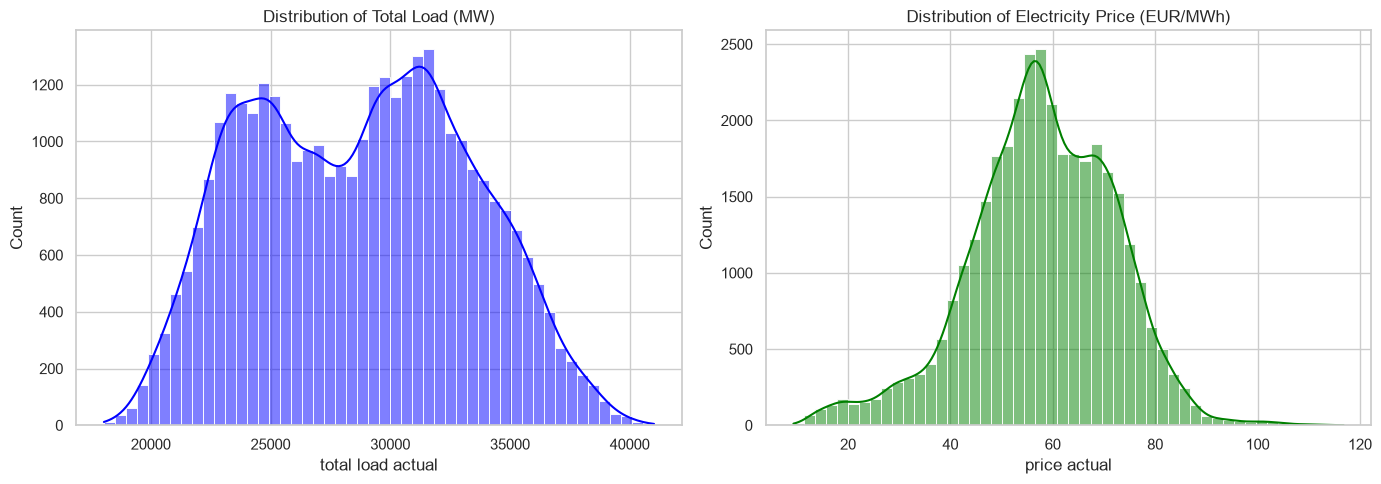

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(merged['total load actual'], bins=50, ax=axes[0], color='blue', kde=True)
axes[0].set_title('Distribution of Total Load (MW)')

sns.histplot(merged['price actual'], bins=50, ax=axes[1], color='green', kde=True)
axes[1].set_title('Distribution of Electricity Price (EUR/MWh)')

plt.tight_layout()
plt.show()

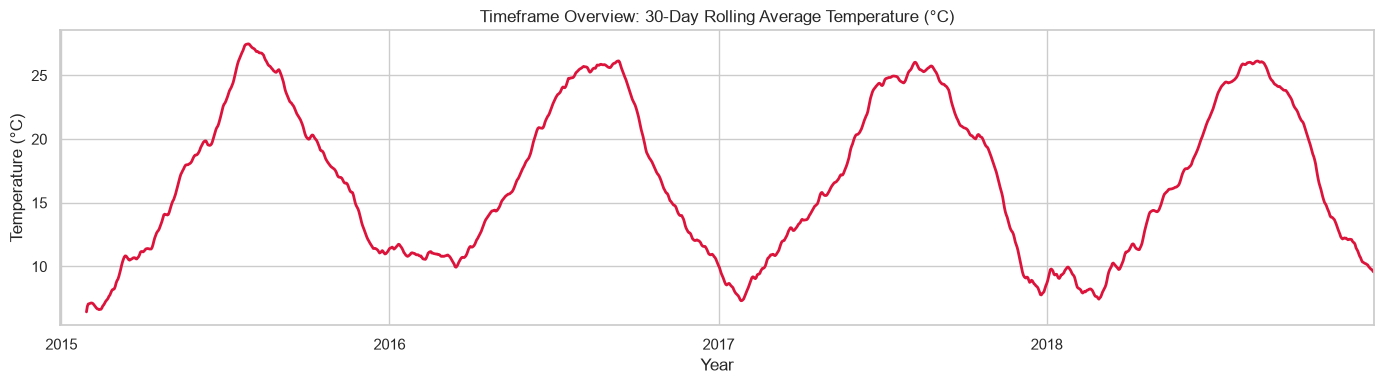

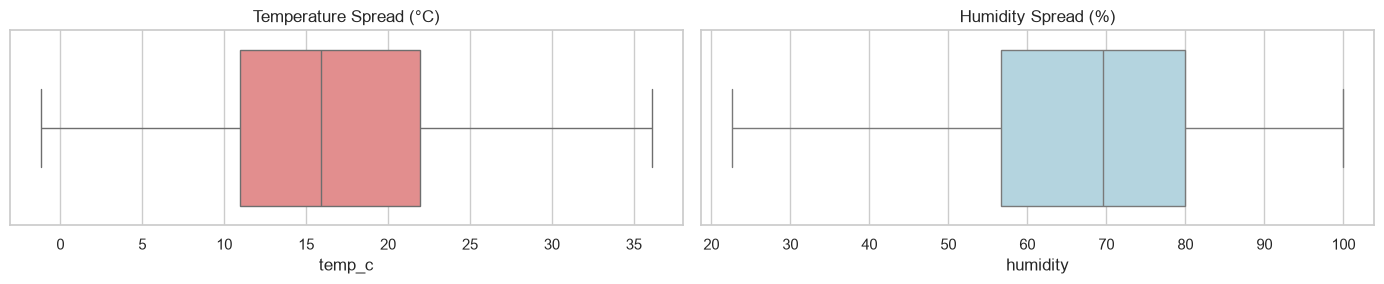

In [7]:
# 1. timeline overview of temperature
plt.figure(figsize=(14, 4))
daily_temp = merged.set_index('time')['temp_c'].resample('D').mean()
daily_temp.rolling(30).mean().plot(color='crimson', linewidth=2)
plt.title('Timeframe Overview: 30-Day Rolling Average Temperature (°C)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

# 2. distribution overview of temperature
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
sns.boxplot(x=merged['temp_c'], ax=axes[0], color='lightcoral')
axes[0].set_title('Temperature Spread (°C)')
sns.boxplot(x=merged['humidity'], ax=axes[1], color='lightblue')
axes[1].set_title('Humidity Spread (%)')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [8]:
# Wo
merged['hour'] = merged['time'].dt.hour
merged['month'] = merged['time'].dt.month
merged['weekday'] = merged['time'].dt.dayofweek
merged['season'] = merged['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

# Feature 1: is_weekend
merged['is_weekend'] = (merged['weekday'] >= 5).astype(int)

# Feature 2: is_peak_hour (Morning 8-11, Evening 18-21)
merged['is_peak_hour'] = merged['hour'].isin([8,9,10,11, 18,19,20,21]).astype(int)

print('New features created: is_weekend, is_peak_hour, season, hour')

New features created: is_weekend, is_peak_hour, season, hour


## 5. Deeper Time & Generation Analysis

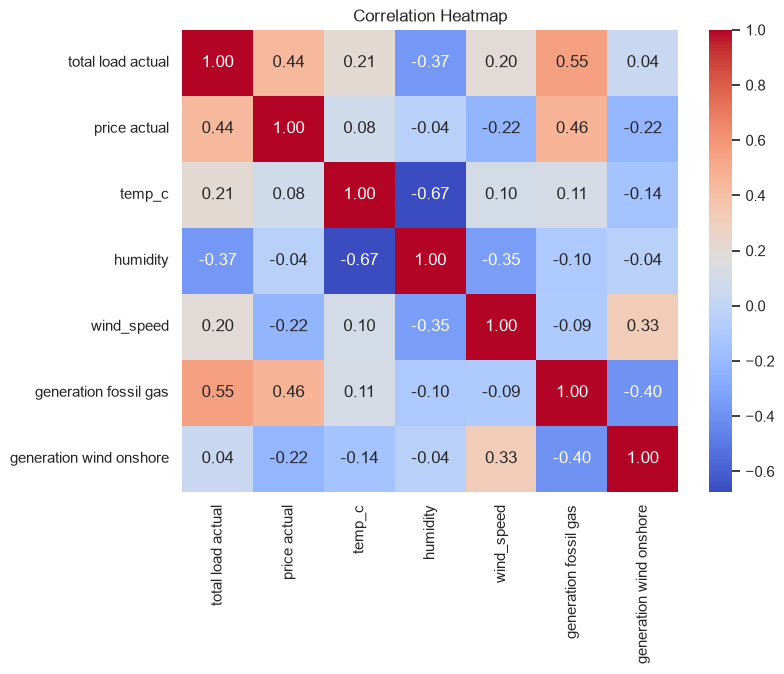

In [9]:
# Correlation heatmap to spot any obvious dependencies
cols = ['total load actual', 'price actual', 'temp_c', 'humidity', 'wind_speed', 'generation fossil gas', 'generation wind onshore']
corr = merged[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

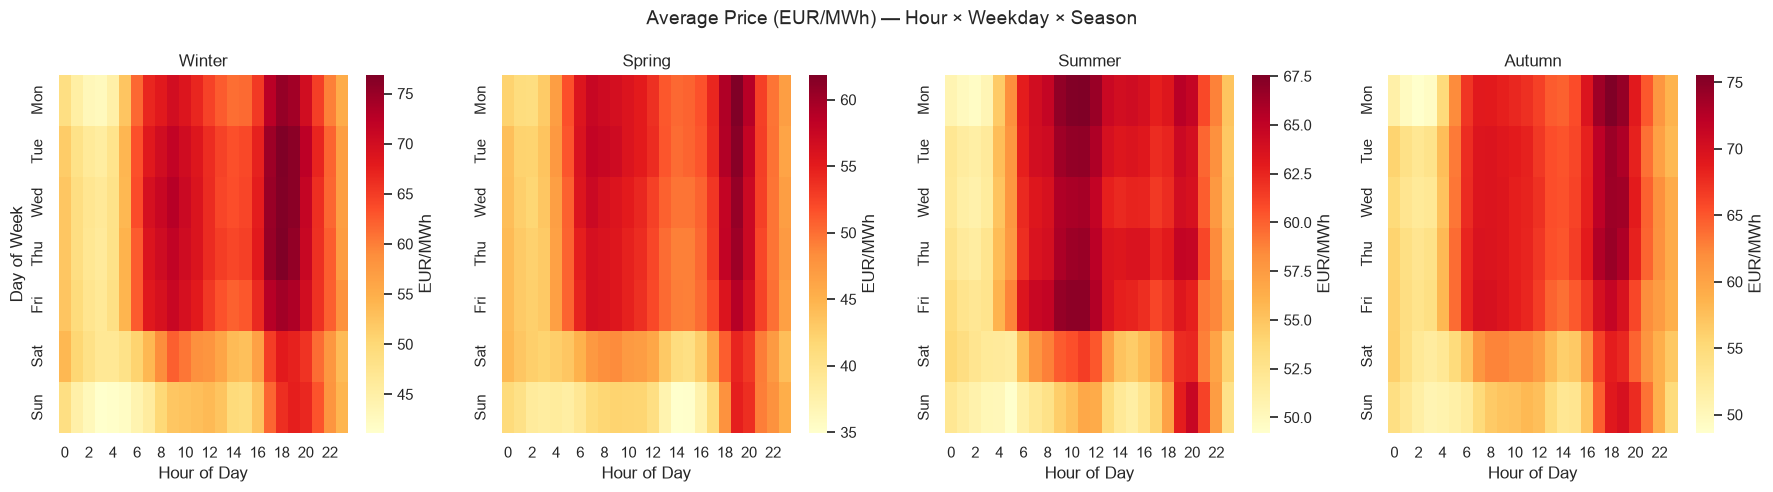

In [10]:
#Looking into seasonal dependencies
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, season in zip(axes, season_order):
    pivot = (
        merged[merged['season'] == season]
        .groupby(['weekday', 'hour'])['price actual']
        .mean()
        .unstack(level='hour')
    )
    pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'EUR/MWh'})
    ax.set_title(f'{season}')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Day of Week' if ax == axes[0] else '')

plt.suptitle('Average Price (EUR/MWh) — Hour × Weekday × Season', fontsize=14)
plt.tight_layout()
plt.show()

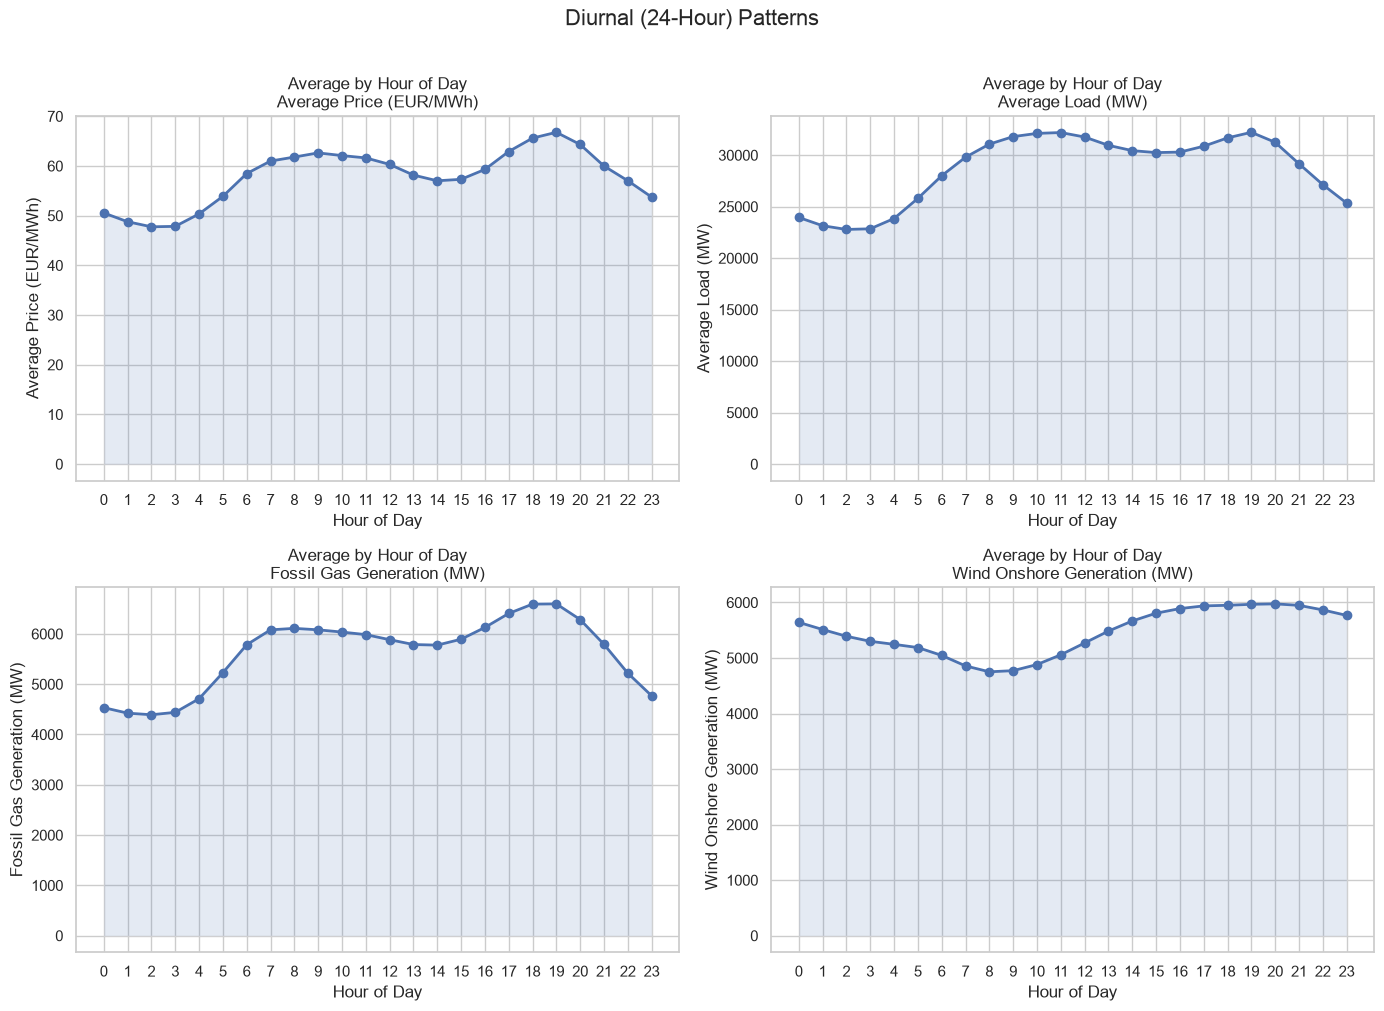

In [13]:
#looking further into diurnal patterns using plots
hourly = merged.groupby('hour')[['price actual', 'total load actual',
                                     'generation fossil gas', 'generation wind onshore']].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

vars_labels = [
    ('price actual',            'Average Price (EUR/MWh)'),
    ('total load actual',       'Average Load (MW)'),
    ('generation fossil gas',   'Fossil Gas Generation (MW)'),
    ('generation wind onshore', 'Wind Onshore Generation (MW)'),
]

for ax, (col, label) in zip(axes, vars_labels):
    ax.plot(hourly.index, hourly[col], marker='o', linewidth=2)
    ax.fill_between(hourly.index, hourly[col], alpha=0.15)
    ax.set_title(f'Average by Hour of Day\n{label}', fontsize=12)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel(label)
    ax.set_xticks(range(0, 24))

plt.suptitle('Diurnal (24-Hour) Patterns', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

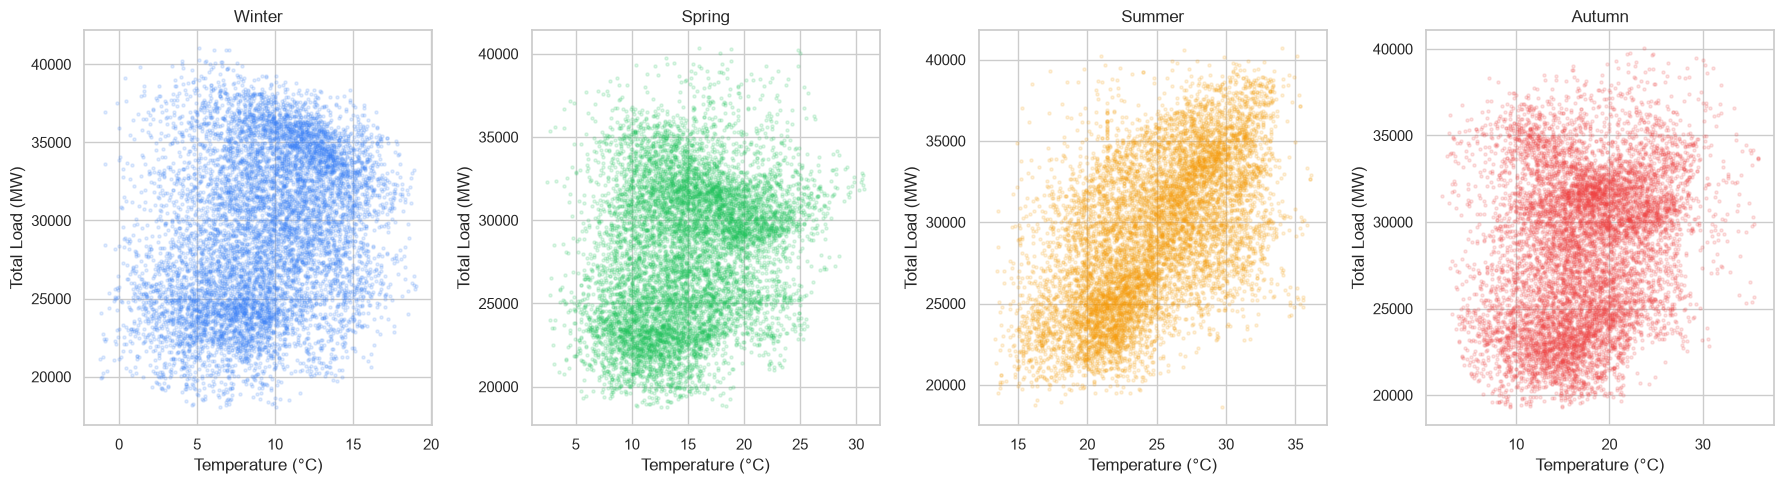

In [14]:
#Turning focus onto temperature-related dependencies using scatter plots
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
palette = {'Winter':'#3b82f6', 'Spring':'#22c55e', 'Summer':'#f59e0b', 'Autumn':'#ef4444'}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, season in zip(axes, season_order):
    sdf = merged[merged['season'] == season]
    ax.scatter(sdf['temp_c'], sdf['total load actual'], alpha=0.15, s=5, color=palette[season])
    ax.set_title(season)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Total Load (MW)')

plt.tight_layout()
plt.show()

## 7. Hypothesis 1: Summer Temperature vs. Load
**Hypothesis:** In the summer, total load has a positive linear dependency on temperature due to air conditioning. However, the baseline load is significantly lower on weekends.

Based on the four-season plot above, we filter specifically to the Summer data where this linear relationship is clearest.

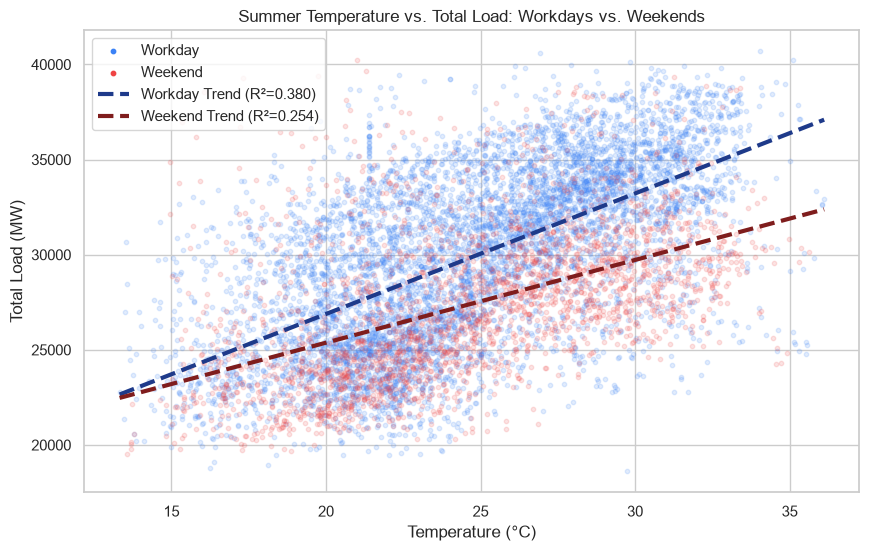

In [11]:
summer_df = merged[merged['season'] == 'Summer'].dropna(subset=['temp_c', 'total load actual']).copy()
workdays = summer_df[summer_df['is_weekend'] == 0]
weekends = summer_df[summer_df['is_weekend'] == 1]

from scipy.stats import linregress
res_work = linregress(workdays['temp_c'], workdays['total load actual'])
res_week = linregress(weekends['temp_c'], weekends['total load actual'])

plt.figure(figsize=(10, 6))
plt.scatter(workdays['temp_c'], workdays['total load actual'], alpha=0.15, s=10, color='#3b82f6', label='Workday')
plt.scatter(weekends['temp_c'], weekends['total load actual'], alpha=0.15, s=10, color='#ef4444', label='Weekend')

xs = np.linspace(summer_df['temp_c'].min(), summer_df['temp_c'].max(), 100)
plt.plot(xs, res_work.intercept + res_work.slope * xs, color='#1e3a8a', linewidth=3, linestyle='--', label=f'Workday Trend (R²={res_work.rvalue**2:.3f})')
plt.plot(xs, res_week.intercept + res_week.slope * xs, color='#7f1d1d', linewidth=3, linestyle='--', label=f'Weekend Trend (R²={res_week.rvalue**2:.3f})')

plt.title('Summer Temperature vs. Total Load: Workdays vs. Weekends')
plt.xlabel('Temperature (°C)')
plt.ylabel('Total Load (MW)')
leg = plt.legend(loc='upper left')
for lh in leg.legend_handles: lh.set_alpha(1)
plt.show()

In [12]:
# Statistical Test for Hypothesis 1
# Using an independent t-test to compare the baseline load of workdays vs weekends
print('--- Statistical Test (T-Test) ---')
t_stat, p_val = stats.ttest_ind(workdays['total load actual'], weekends['total load actual'], equal_var=False)
print(f'Workday Mean Load: {workdays["total load actual"].mean():.0f} MW | Weekend Mean Load: {weekends["total load actual"].mean():.0f} MW')
print(f'T-test p-value: {p_val:.2e}')
print('\nConclusion: The p-value is < 0.05, statistically confirming that weekends have a significantly lower structural load baseline.')

--- Statistical Test (T-Test) ---
Workday Mean Load: 29867 MW | Weekend Mean Load: 27382 MW
T-test p-value: 1.26e-137

Conclusion: The p-value is < 0.05, statistically confirming that weekends have a significantly lower structural load baseline.


## 8. Hypothesis 2: Diurnal Peaks in Load and Price
**Hypothesis:** There are two distinct peaks in load and prices during the day (morning and evening), driven by human behavior and the marginal cost of peaking power plants.

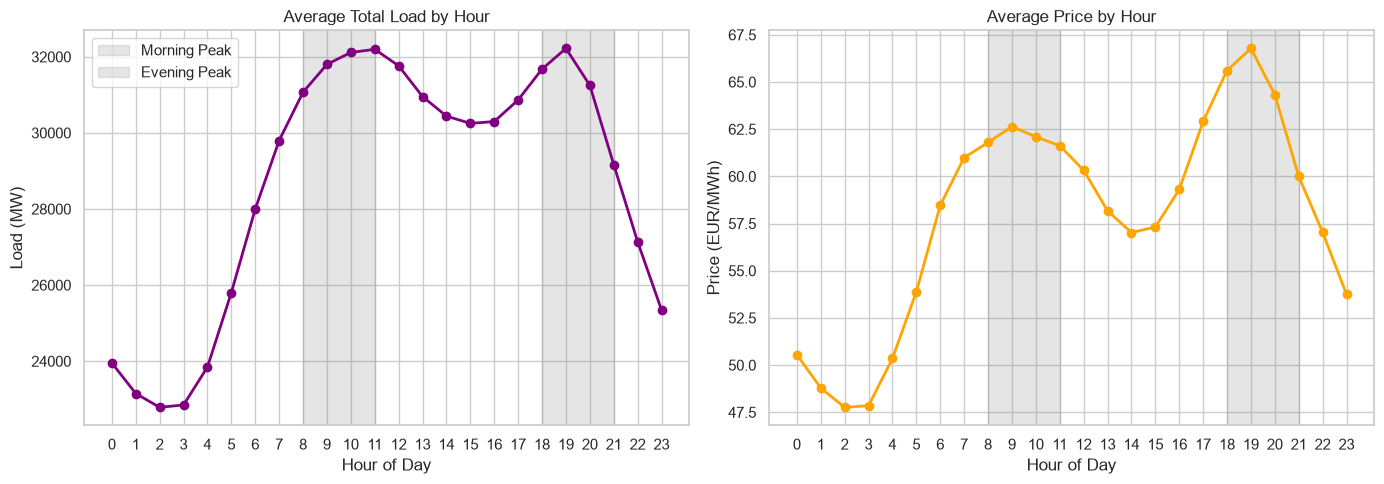

In [13]:
hourly = merged.groupby('hour')[['total load actual', 'price actual']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly['hour'], hourly['total load actual'], marker='o', linewidth=2, color='purple')
axes[0].set_title('Average Total Load by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Load (MW)')
axes[0].set_xticks(range(0, 24))
axes[0].axvspan(8, 11, color='gray', alpha=0.2, label='Morning Peak')
axes[0].axvspan(18, 21, color='gray', alpha=0.2, label='Evening Peak')
axes[0].legend()

axes[1].plot(hourly['hour'], hourly['price actual'], marker='o', linewidth=2, color='orange')
axes[1].set_title('Average Price by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Price (EUR/MWh)')
axes[1].set_xticks(range(0, 24))
axes[1].axvspan(8, 11, color='gray', alpha=0.2)
axes[1].axvspan(18, 21, color='gray', alpha=0.2)

plt.tight_layout()
plt.show()

In [14]:
# Statistical Test for Hypothesis 2
# Using an independent t-test to compare peak vs off-peak hours
print('--- Statistical Test (T-Test) ---')
peak_load = merged[merged['is_peak_hour'] == 1]['total load actual']
offpeak_load = merged[merged['is_peak_hour'] == 0]['total load actual']

t_stat_load, p_val_load = stats.ttest_ind(peak_load, offpeak_load, equal_var=False)
print(f'Total Load -> Peak Mean: {peak_load.mean():.0f} MW | Off-Peak Mean: {offpeak_load.mean():.0f} MW')
print(f'T-test p-value: {p_val_load:.2e}')

peak_price = merged[merged['is_peak_hour'] == 1]['price actual']
offpeak_price = merged[merged['is_peak_hour'] == 0]['price actual']

t_stat_price, p_val_price = stats.ttest_ind(peak_price, offpeak_price, equal_var=False)
print(f'\nPrice -> Peak Mean: {peak_price.mean():.2f} EUR | Off-Peak Mean: {offpeak_price.mean():.2f} EUR')
print(f'T-test p-value: {p_val_price:.2e}')
print('\nConclusion: Both p-values are < 0.05, statistically confirming that load and prices are significantly higher during the defined peak hours.')

--- Statistical Test (T-Test) ---
Total Load -> Peak Mean: 31437 MW | Off-Peak Mean: 27327 MW
T-test p-value: 0.00e+00

Price -> Peak Mean: 63.11 EUR | Off-Peak Mean: 55.28 EUR
T-test p-value: 0.00e+00

Conclusion: Both p-values are < 0.05, statistically confirming that load and prices are significantly higher during the defined peak hours.
